In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
from tensorflow.keras.preprocessing import image

In [3]:
#loading the data set
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

In [4]:
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [5]:

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0 
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

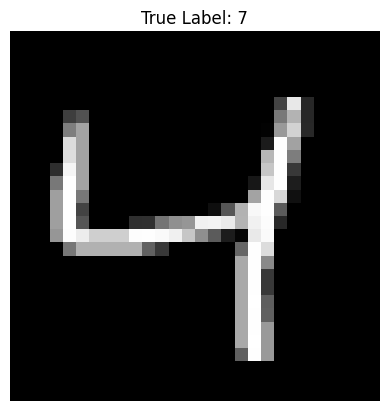

In [6]:
#shows the image at that index
import matplotlib.pyplot as plt
plt.imshow(x_train[2].reshape(28, 28), cmap='gray')
plt.title(f"True Label: {y_test[0]}")
plt.axis('off')
plt.show()

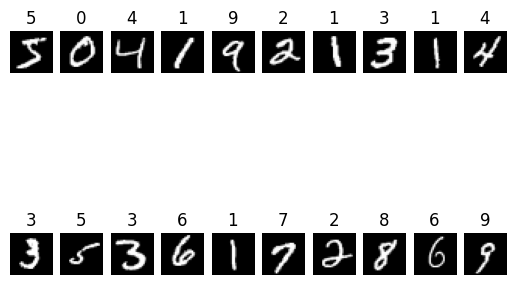

In [7]:
#training data pics
for i in range(20):
    plt.subplot(2,10,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"{y_train[i]}")
    plt.axis('off')

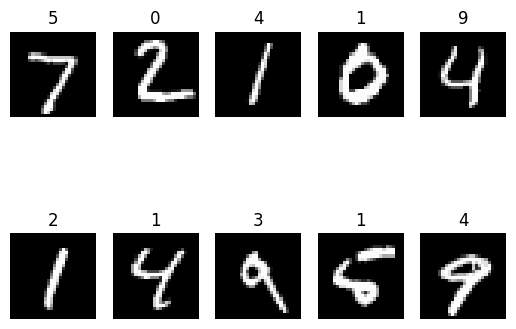

In [8]:
#testing data pics
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"{y_train[i]}")
    plt.axis('off')

In [9]:
# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

c:\Users\KIRAN GHANTASALA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Compile and train
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
model.fit(x_train, y_train, epochs=10,validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9094 - loss: 0.2961 - val_accuracy: 0.9833 - val_loss: 0.0488
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9651 - loss: 0.1208 - val_accuracy: 0.9875 - val_loss: 0.0376
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9722 - loss: 0.0955 - val_accuracy: 0.9869 - val_loss: 0.0428
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9776 - loss: 0.0773 - val_accuracy: 0.9904 - val_loss: 0.0312
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9799 - loss: 0.0670 - val_accuracy: 0.9890 - val_loss: 0.0348
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9829 - loss: 0.0565 - val_accuracy: 0.9916 - val_loss: 0.0283
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9842 - loss: 0.0516 - val_accuracy: 0.9918 - val_loss: 0.0317
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9858 -

In [12]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9932 - loss: 0.0259


[0.025927944108843803, 0.9932000041007996]

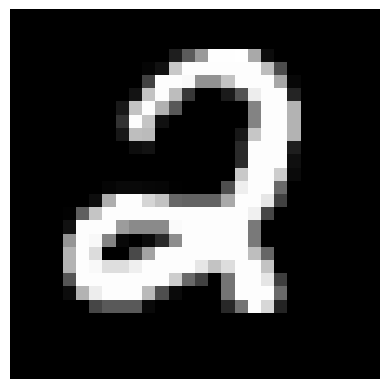

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2
True label: 2
Predicted class: 2


In [13]:
# Pick a sample image from test set 
sample_index = 147
img = x_test[sample_index] 
true_label = y_test[sample_index]
# Show the image 
plt.imshow(img.reshape(28,28), cmap='gray') 
plt.axis('off') 
plt.show()
# Predict on testing data
img = np.expand_dims(img, axis=0)          
predictions = model.predict(img) 
predicted_class = np.argmax(predictions[0])
print(predicted_class)
print("True label:", true_label) 
print("Predicted class:", predicted_class)

In [14]:
from sklearn.metrics import classification_report,accuracy_score

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))
print(accuracy_score(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      1.00      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

0.9932


In [15]:
import pickle
with open("model_cnn.pkl", "wb") as f:
    pickle.dump(model,f)

In [16]:

# Save the trained model
model.save("mnist_cnn_model.h5")

In [17]:
from tensorflow.keras.models import load_model
model = load_model("mnist_cnn_model.h5")